In [1]:
import csv
import os 
import torch 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
file_path = "/Users/miguelmartins/Projects/Understanding-ESSL/Equivariant_Network/"

In [7]:
log_path = f"{file_path}logs/0"

logs = [
    os.path.join(log_path, file)
    for file in os.listdir(log_path)
    
]
import pandas as pd

# Path to your file


print(file_path)


def get_df(file_path):
    # --- Step 1: Read the file lines
    # Read raw rows with csv to be robust to commas/quotes
    with open(file_path, newline="") as f:
        rows = list(csv.reader(f))
    
    # Find the table header row ("epoch,train_acc,...")
    header_idx = next(i for i, r in enumerate(rows) if r and r[0].strip() == "epoch")
    
    # --- Parse metadata safely (only rows with exactly two cells)
    metadata = {}
    for r in rows[:header_idx]:
        if len(r) == 2:  # skip lines like ['""'] or ['']
            k, v = r
            metadata[k.strip()] = v.strip()
    
    # --- Parse the training table
    header = rows[header_idx]
    data = rows[header_idx + 1:]
    df = pd.DataFrame(data, columns=header)
    
    # Make numeric columns numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    
    return df



FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguelmartins/Projects/Understanding-ESSL/Equivariant_Network/logs/0'

In [172]:
log_dict = {"res_none_probe": "logs/cifar10_probe_resnet18_2_2_0.2_aug_nonehead_linear202510281543.csv",
            "res_sup_probe": "logs/cifar10_probe_resnet18_2_2_0.2_aug_nonehead_linear202510281544.csv",
            "res_simclr_probe": "logs/cifar10_probe_resnet18_2_2_0.2_aug_nonehead_linear202510281545.csv"
           }


In [173]:
log_dfs = {}
for name, log in log_dict.items():
    log_dfs[name] = get_df(log)
    print(log_dfs[name]["test_acc"].iloc[-1], log_dfs[name]["test_acc"].iloc[np.argmax(log_dfs[name]["test_acc"])])

0.4412 0.4521
0.4749 0.4834
0.59 0.597


In [174]:
log_dict_pre = {"res_none_probe": "logs/cifar10_resnet18_2_2_0.2_aug_nonehead_mlp202510280658.csv",
            "res_sup_probe": "logs/cifar10_resnet18_2_2_0.2_aug_suphead_mlp202510271017.csv",
            "res_simclr_probe": "logs/cifar10_resnet18_2_2_0.2_aug_simclrhead_mlp202510271501.csv"
           }

log_dfs_pre = {}
for name, log in log_dict_pre.items():
    log_dfs_pre[name] = get_df(log)
    print(log_dfs_pre[name]["test_acc"].iloc[-1], log_dfs_pre[name]["rot_acc"])

0.5232 0      0.49352
1      0.59136
2      0.62048
3      0.64924
4      0.67652
        ...   
195    0.99974
196    0.99980
197    0.99968
198    0.99974
199    0.99974
Name: rot_acc, Length: 200, dtype: float64
0.5487 0      0.52602
1      0.60198
2      0.63754
3      0.66824
4      0.69166
        ...   
195    0.99844
196    0.99874
197    0.99866
198    0.99852
199    0.99838
Name: rot_acc, Length: 200, dtype: float64
0.6295 0      0.38018
1      0.43502
2      0.43990
3      0.45606
4      0.47674
        ...   
195    0.84006
196    0.84132
197    0.83848
198    0.83846
199    0.83872
Name: rot_acc, Length: 200, dtype: float64


[]

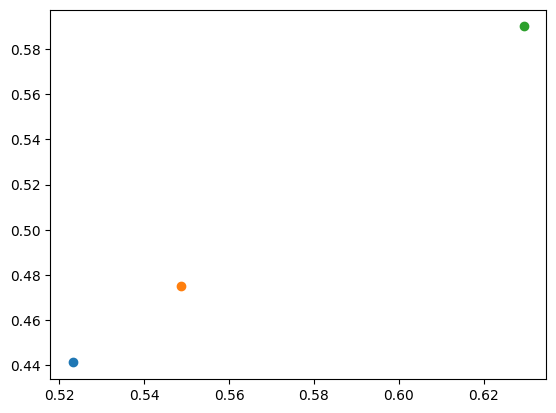

In [175]:
for name in log_dict.keys():
    plt.scatter(log_dfs_pre[name]["test_acc"].iloc[-1], log_dfs[name]["test_acc"].iloc[-1])
plt.plot()

In [188]:
def plot_logdict_scatter(
    pre_logs: dict,
    post_logs: dict,
    column: str = "test_acc",
    names=None,
    ax=None,
    title: str | None = None,
    show_diagonal: bool = True,
    point_kwargs=None,
    label_kwargs=None,
    frontier_kwargs=None,
):
    """
    Scatter compare the last values of `column` from two log dictionaries.

    Parameters
    ----------
    pre_logs : dict[str, pd.DataFrame]
        Mapping run name -> DataFrame with a column `column`. X-axis uses the last non-null value.
    post_logs : dict[str, pd.DataFrame]
        Mapping run name -> DataFrame with a column `column`. Y-axis uses the last non-null value.
    column : str
        Column name to compare (e.g., "test_acc", "loss", etc.).
    names : list[str] | None
        Subset of run names to include. By default uses intersection of keys in both dicts.
    ax : matplotlib.axes.Axes | None
        Axes to draw on. Creates a new one if None.
    title : str | None
        Plot title.
    show_diagonal : bool
        If True, draw the y = x line as a reference.
    point_kwargs : dict | None
        Extra kwargs for plt.scatter (e.g., {'s': 50, 'alpha': 0.8}).
    label_kwargs : dict | None
        Extra kwargs for text labels (e.g., {'fontsize': 9, 'ha': 'left', 'va': 'bottom'}).
    frontier_kwargs : dict | None
        Extra kwargs for Pareto frontier line (e.g., {'linewidth': 2}).

    Returns
    -------
    dict
        {'data': pd.DataFrame, 'pareto_names': list[str]}
        data has columns ['name','x','y'].
    """
    point_kwargs = point_kwargs or {}
    label_kwargs = label_kwargs or {"fontsize": 8, "ha": "left", "va": "bottom"}
    frontier_kwargs = frontier_kwargs or {"linewidth": 2}

    # Determine the names to include
    if names is None:
        names = sorted(set(pre_logs.keys()) & set(post_logs.keys()))
    else:
        names = [n for n in names if n in pre_logs and n in post_logs]

    # Helper to get the last non-null value
    def last_value(df: pd.DataFrame, col: str):
        if col not in df.columns:
            return np.nan
        s = df[col].dropna()
        return s.iloc[-1] if len(s) else np.nan

    # Collect points
    rows = []
    for n in names:
        x = last_value(pre_logs[n], column)
        y = last_value(post_logs[n], column)
        if not (isinstance(x, (int, float, np.floating)) and isinstance(y, (int, float, np.floating))):
            continue
        if np.isfinite(x) and np.isfinite(y):
            rows.append((n, float(x), float(y)))

    data = pd.DataFrame(rows, columns=["name", "x", "y"])
    if data.empty:
        raise ValueError(f"No finite values found for column '{column}' in provided logs.")

    # Build plot
    if ax is None:
        fig, ax = plt.subplots()

    # Scatter points
    ax.scatter(data["x"], data["y"], **point_kwargs)

    # Labels
    for _, r in data.iterrows():
        ax.text(r["x"], r["y"], f" {r['name']}", **label_kwargs)

    # y=x diagonal
    if show_diagonal:
        xy_min = min(data["x"].min(), data["y"].min())
        xy_max = max(data["x"].max(), data["y"].max())
        margin = 0.05 * (xy_max - xy_min if xy_max > xy_min else 1.0)
        ax.plot([xy_min - margin, xy_max + margin], [xy_min - margin, xy_max + margin], linestyle="--", alpha=0.6)

    # Compute Pareto frontier (upper-right, non-dominated: maximize both x and y)
    # A point i is dominated if there exists j with x_j >= x_i and y_j >= y_i and at least one strict.
    def is_dominated(i, pts):
        xi, yi = pts[i]
        for j, (xj, yj) in enumerate(pts):
            if j == i: 
                continue
            if (xj >= xi and yj >= yi) and (xj > xi or yj > yi):
                return True
        return False

    pts = list(zip(data["x"].tolist(), data["y"].tolist()))
    non_dom_idx = [i for i in range(len(pts)) if not is_dominated(i, pts)]
    pareto = data.iloc[non_dom_idx].copy()

    # Sort the frontier for plotting as an upper-right envelope
    pareto = pareto.sort_values(["x", "y"], ascending=[True, False])

    # Draw the Pareto frontier as a polyline
    ax.plot(pareto["x"].values, pareto["y"].values, marker="o", linestyle="-", **frontier_kwargs)

    # Ax labels and title
    ax.set_xlabel(f"Pre: {column}")
    ax.set_ylabel(f"Post: {column}")
    if title is None:
        title = f"Comparison of '{column}' (last values): Pre vs Post\n(Pareto frontier shown; maximizing both)"
    ax.set_title(title)

    # Nice limits
    xmin, xmax = data["x"].min(), data["x"].max()
    ymin, ymax = data["y"].min(), data["y"].max()
    xr = xmax - xmin if xmax > xmin else 1.0
    yr = ymax - ymin if ymax > ymin else 1.0
    ax.set_xlim(xmin - 0.05 * xr, xmax + 0.05 * xr)
    ax.set_ylim(ymin - 0.05 * yr, ymax + 0.05 * yr)

    ax.grid(True, linestyle=":", alpha=0.5)

    return {
        "data": data,
        "pareto_names": pareto["name"].tolist(),
    }

In [189]:
result = plot_logdict_scatter(log_dfs_pre, log_dfs, pre_column="test_acc", post_column="test_acc")
plt.show()

TypeError: plot_logdict_scatter() got an unexpected keyword argument 'pre_column'

In [208]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_logdict_scatter(
    pre_logs: dict,
    post_logs: dict,
    pre_column: str = "test_acc",
    post_column: str = "test_acc",
    names=None,
    ax=None,
    title: str | None = None,
    show_diagonal: bool = True,
    point_kwargs=None,
    label_kwargs=None,
    frontier_kwargs=None,
    xlabel: str | None = None,
    ylabel: str | None = None,
):
    """
    Compare last values from two log dictionaries, possibly using different columns.

    Parameters
    ----------
    pre_logs, post_logs : dict[str, pd.DataFrame]
        Mapping run name -> DataFrame.
    pre_column : str
        Column to use for X values from pre_logs.
    post_column : str
        Column to use for Y values from post_logs.
    names : list[str] | None
        Subset of run names to include. Defaults to key intersection.
    ax : matplotlib.axes.Axes | None
        Axes to draw on. Creates a new one if None.
    title : str | None
        Plot title.
    show_diagonal : bool
        Draw y=x reference line (useful if columns are comparable).
    point_kwargs, label_kwargs, frontier_kwargs : dict | None
        Styling kwargs for points, labels, and Pareto frontier.
    xlabel, ylabel : str | None
        Override auto-generated axis labels. If None, auto labels are used.

    Returns
    -------
    dict
        {'data': pd.DataFrame, 'pareto_names': list[str]}
    """
    point_kwargs = point_kwargs or {}
    label_kwargs = label_kwargs or {"fontsize": 8, "ha": "left", "va": "bottom"}
    frontier_kwargs = frontier_kwargs or {"linewidth": 2}

    # Determine the names to include
    if names is None:
        names = sorted(set(pre_logs.keys()) & set(post_logs.keys()))
    else:
        names = [n for n in names if n in pre_logs and n in post_logs]

    def last_value(df: pd.DataFrame, col: str):
        if col not in df.columns:
            return np.nan
        s = df[col].dropna()
        return np.max(s) if len(s) else np.nan

    rows = []
    for n in names:
        x = last_value(pre_logs[n], pre_column)
        y = last_value(post_logs[n], post_column)
        if np.isfinite(x) and np.isfinite(y):
            rows.append((n, float(x), float(y)))

    data = pd.DataFrame(rows, columns=["name", "x", "y"])
    if data.empty:
        raise ValueError(
            f"No finite values found for columns '{pre_column}' (pre) and '{post_column}' (post)."
        )

    if ax is None:
        fig, ax = plt.subplots()

    # Scatter + labels
    ax.scatter(data["x"], data["y"], **point_kwargs)
    for _, r in data.iterrows():
        ax.text(r["x"], r["y"], f" {r['name']}", **label_kwargs)

    # Optional y=x
    if show_diagonal:
        xy_min = min(data["x"].min(), data["y"].min())
        xy_max = max(data["x"].max(), data["y"].max())
        margin = 0.05 * (xy_max - xy_min if xy_max > xy_min else 1.0)
        ax.plot([xy_min - margin, xy_max + margin],
                [xy_min - margin, xy_max + margin],
                linestyle="--", alpha=0.6)

    # Pareto frontier (maximize both axes)
    pts = data[["x","y"]].to_numpy()
    non_dom = []
    for i, (xi, yi) in enumerate(pts):
        dominated = False
        for j, (xj, yj) in enumerate(pts):
            if j == i: 
                continue
            if (xj >= xi and yj >= yi) and (xj > xi or yj > yi):
                dominated = True
                break
        if not dominated:
            non_dom.append(i)

    pareto = data.iloc[non_dom].copy()
    pareto = pareto.sort_values(["x", "y"], ascending=[True, False])
    ax.plot(pareto["x"].values, pareto["y"].values, marker="o", linestyle="-", **frontier_kwargs)

    # Labels and title
    ax.set_xlabel(xlabel if xlabel is not None else f"Pre: {pre_column}")
    ax.set_ylabel(ylabel if ylabel is not None else f"Post: {post_column}")
    if title is None:
        title = f"Pre ({pre_column}) vs Post ({post_column}) — last values\n(Pareto frontier shown; maximizing both)"
    ax.set_title(title)

    # Margins & grid

    #ax.set_xlim(xmin - 0.1 * xr, xmax + 0.1 * xr)
    #ax.set_ylim(ymin - 0.1 * yr, ymax + 0.1 * yr)
    
    ax.grid(True, linestyle=":", alpha=0.5)

    return {"data": data, "pareto_names": pareto["name"].tolist()}


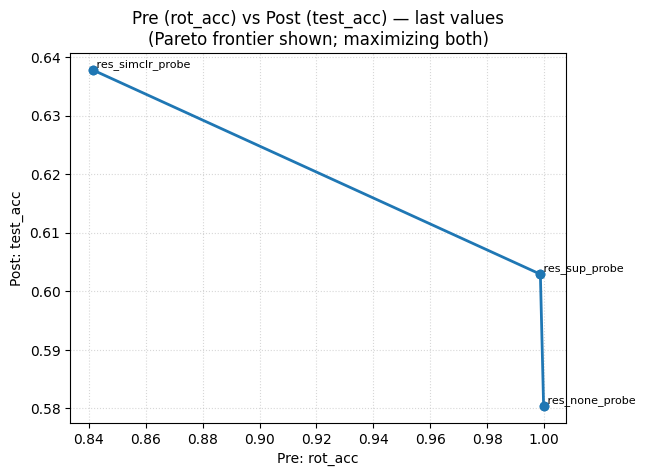

In [210]:
res = plot_logdict_scatter(log_dfs_pre, log_dfs_pre, pre_column="rot_acc", post_column="test_acc", show_diagonal=False)
plt.show()

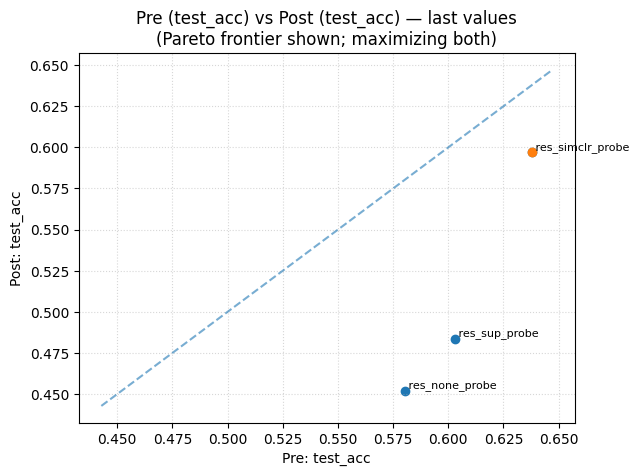

In [192]:
res = plot_logdict_scatter(log_dfs_pre, log_dfs, pre_column="test_acc", post_column="test_acc")
plt.show()

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.transforms import offset_copy
from matplotlib.ticker import PercentFormatter

def plot_logdict_scatter(
    pre_logs: dict,
    post_logs: dict,
    pre_column: str = "test_acc",
    post_column: str = "test_acc",
    names=None,
    ax=None,
    title: str | None = None,
    show_diagonal: bool = True,
    point_kwargs=None,
    label_kwargs=None,
    frontier_kwargs=None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize=(7, 6),
    percent_axes: bool | None = None,
    text_offset_pts=(4, 4),
):
    point_defaults = dict(s=70, alpha=0.85, linewidths=0.5, edgecolors="black")
    label_defaults = dict(fontsize=9, ha="left", va="bottom")
    frontier_defaults = dict(linewidth=2.0, linestyle="-", marker="o")

    point_kwargs = {**point_defaults, **(point_kwargs or {})}
    label_kwargs = {**label_defaults, **(label_kwargs or {})}
    frontier_kwargs = {**frontier_defaults, **(frontier_kwargs or {})}

    if names is None:
        names = sorted(set(pre_logs.keys()) & set(post_logs.keys()))
    else:
        names = [n for n in names if n in pre_logs and n in post_logs]

    def last_value(df: pd.DataFrame, col: str):
        if col not in df.columns:
            return np.nan
        s = df[col].dropna()
        return s.iloc[-1] if len(s) else np.nan

    rows = []
    for n in names:
        x = last_value(pre_logs[n], pre_column)
        y = last_value(post_logs[n], post_column)
        if np.isfinite(x) and np.isfinite(y):
            rows.append((n, float(x), float(y)))

    data = pd.DataFrame(rows, columns=["name", "x", "y"])
    if data.empty:
        raise ValueError(
            f"No finite values found for columns '{pre_column}' (pre) and '{post_column}' (post)."
        )

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    ax.scatter(data["x"], data["y"], label="Runs", **point_kwargs)

    # ✅ FIX: pass fig=ax.figure
    text_transform = offset_copy(
        ax.transData, x=text_offset_pts[0], y=text_offset_pts[1],
        units='points', fig=ax.figure
    )
    for _, r in data.iterrows():
        ax.text(r["x"], r["y"], f"{r['name']}", transform=text_transform, **label_kwargs)

    if show_diagonal:
        xy_min = min(data["x"].min(), data["y"].min())
        xy_max = max(data["x"].max(), data["y"].max())
        pad = 0.05 * (xy_max - xy_min if xy_max > xy_min else 1.0)
        ax.plot([xy_min - pad, xy_max + pad],
                [xy_min - pad, xy_max + pad],
                linestyle="--", linewidth=1.0, alpha=0.6, label="y = x", zorder=0)

    pts = data[["x", "y"]].to_numpy()
    non_dom = []
    for i, (xi, yi) in enumerate(pts):
        dominated = any(
            (xj >= xi and yj >= yi) and (xj > xi or yj > yi)
            for j, (xj, yj) in enumerate(pts) if j != i
        )
        if not dominated:
            non_dom.append(i)

    pareto = data.iloc[non_dom].sort_values(["x", "y"], ascending=[True, False])
    ax.plot(pareto["x"].values, pareto["y"].values, label="Pareto frontier", **frontier_kwargs)

    ax.set_xlabel(xlabel if xlabel is not None else f"Pre: {pre_column}")
    ax.set_ylabel(ylabel if ylabel is not None else f"Post: {post_column}")
    if title is None:
        title = f"Pre ({pre_column}) vs Post ({post_column}) — last values"
    ax.set_title(title)

    xmin, xmax = data["x"].min(), data["x"].max()
    ymin, ymax = data["y"].min(), data["y"].max()
    xr = xmax - xmin if xmax > xmin else 1.0
    yr = ymax - ymin if ymax > ymin else 1.0
    ax.set_xlim(xmin - 0.1 * xr, xmax + 0.1 * xr)
    ax.set_ylim(ymin - 0.1 * yr, ymax + 0.1 * yr)
    ax.grid(True, linestyle=":", alpha=0.55)
    ax.legend(loc="best", frameon=True)

    if percent_axes is None:
        percent_axes = (0.0 <= xmin <= 1.0 and 0.0 <= xmax <= 1.0 and
                        0.0 <= ymin <= 1.0 and 0.0 <= ymax <= 1.0)
    if percent_axes:
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    return {"ax": ax, "data": data, "pareto_names": pareto["name"].tolist()}


{'data':                name       x        y
 0    res_none_probe  0.5804  0.99988
 1  res_simclr_probe  0.6378  0.84132
 2     res_sup_probe  0.6029  0.99874,
 'pareto_names': ['res_none_probe', 'res_sup_probe', 'res_simclr_probe']}

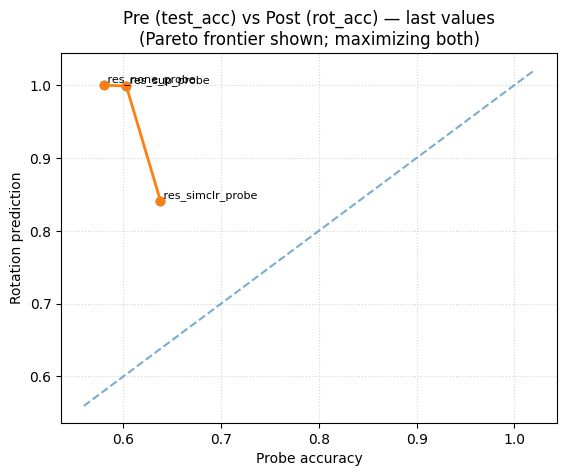

In [193]:

plot_logdict_scatter(
    log_dfs_pre, log_dfs_pre, 
    xlabel="Probe accuracy", ylabel="Rotation prediction", pre_column="test_acc", post_column="rot_acc"
)


{'data':                name       x        y
 0    res_none_probe  0.4521  0.99988
 1  res_simclr_probe  0.5970  0.84132
 2     res_sup_probe  0.4834  0.99874,
 'pareto_names': ['res_none_probe', 'res_sup_probe', 'res_simclr_probe']}

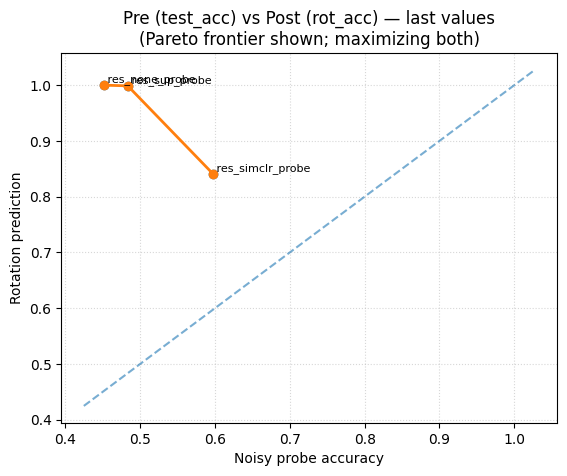

In [187]:

plot_logdict_scatter(
    log_dfs, log_dfs_pre, 
    xlabel="Noisy probe accuracy", ylabel="Rotation prediction", pre_column="test_acc", post_column="rot_acc"
)


{'data':                name       x       y
 0    res_none_probe  0.5804  0.4521
 1  res_simclr_probe  0.6378  0.5970
 2     res_sup_probe  0.6029  0.4834,
 'pareto_names': ['res_simclr_probe']}

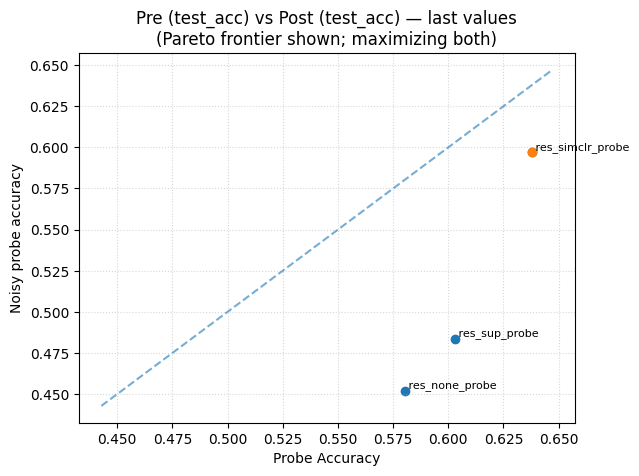

In [203]:

plot_logdict_scatter(
    log_dfs_pre, log_dfs, 
    ylabel="Noisy probe accuracy", xlabel="Probe Accuracy", pre_column="test_acc", post_column="test_acc"
)


In [5]:
log_dict_2 = {"c4_none_probe": "logs/cifar10_probe_resnet18_2_2_0.2_aug_nonehead_linear202510290711.csv",
            "c4_sup_probe": "logs/cifar10_probe_c4_2_2_0.2_aug_suphead_mlp202510300418.csv",
            "c4_simclr_probe": "logs/cifar10_probe_resnet18_2_2_0.2_aug_nonehead_linear202510290712.csv"
           }

In [6]:
log_dfs_2 = {}
for name, log in log_dict_2.items():
    log_dfs_2[name] = get_df(log)
    

NameError: name 'get_df' is not defined

In [201]:
log_dict_pre_2 = {"c4_none_probe": "logs/cifar10_C4resnet18_2_2_0.2_aug_nonehead_mlp202510281542.csv",
            "c4_sup_probe": "logs/cifar10_C4resnet18_2_2_0.2_aug_suphead_mlp202510290706.csv",
            "c4_simclr_probe": "logs/cifar10_C4resnet18_2_2_0.2_aug_simclrhead_mlp202510281541.csv"
           }

log_dfs_pre_2 = {}
for name, log in log_dict_pre_2.items():
    log_dfs_pre_2[name] = get_df(log)

{'data':               name       x        y
 0    c4_none_probe  0.7479  1.00000
 1  c4_simclr_probe  0.8311  0.93274
 2     c4_sup_probe  0.7975  1.00000,
 'pareto_names': ['c4_sup_probe', 'c4_simclr_probe']}

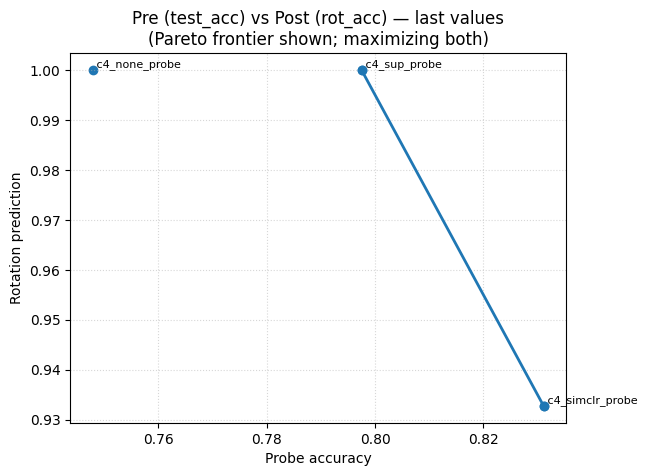

In [221]:
plot_logdict_scatter(
    log_dfs_pre_2, log_dfs_pre_2, 
    xlabel="Probe accuracy", ylabel="Rotation prediction", pre_column="test_acc", post_column="rot_acc", show_diagonal=False
)


{'data':               name       x       y
 0    c4_none_probe  0.7479  0.6620
 1  c4_simclr_probe  0.8311  0.7936
 2     c4_sup_probe  0.7975  0.7322,
 'pareto_names': ['c4_simclr_probe']}

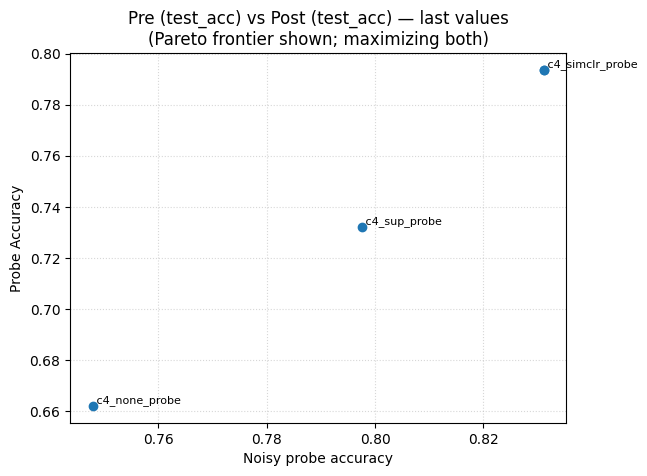

In [224]:

plot_logdict_scatter(
    log_dfs_pre_2, log_dfs_2, show_diagonal=False, 
    xlabel="Noisy probe accuracy", ylabel="Probe Accuracy", pre_column="test_acc", post_column="test_acc"
)


In [225]:
joint_pre = log_dfs_pre | log_dfs_pre_2 
joint = log_dfs | log_dfs_2

{'data':                name       x        y
 0     c4_none_probe  0.7479  1.00000
 1   c4_simclr_probe  0.8311  0.93274
 2      c4_sup_probe  0.7975  1.00000
 3    res_none_probe  0.5804  0.99988
 4  res_simclr_probe  0.6378  0.84132
 5     res_sup_probe  0.6029  0.99874,
 'pareto_names': ['c4_sup_probe', 'c4_simclr_probe']}

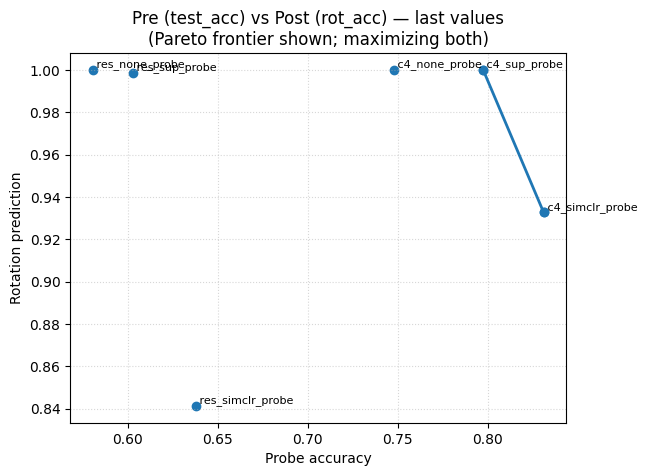

In [226]:
plot_logdict_scatter(
    joint_pre, joint_pre,
    xlabel="Probe accuracy", ylabel="Rotation prediction", pre_column="test_acc", post_column="rot_acc", show_diagonal=False
)


{'data':                name       x       y
 0     c4_none_probe  0.7479  0.7479
 1   c4_simclr_probe  0.8311  0.8311
 2      c4_sup_probe  0.7975  0.7975
 3    res_none_probe  0.5804  0.5804
 4  res_simclr_probe  0.6378  0.6378
 5     res_sup_probe  0.6029  0.6029,
 'pareto_names': ['c4_simclr_probe']}

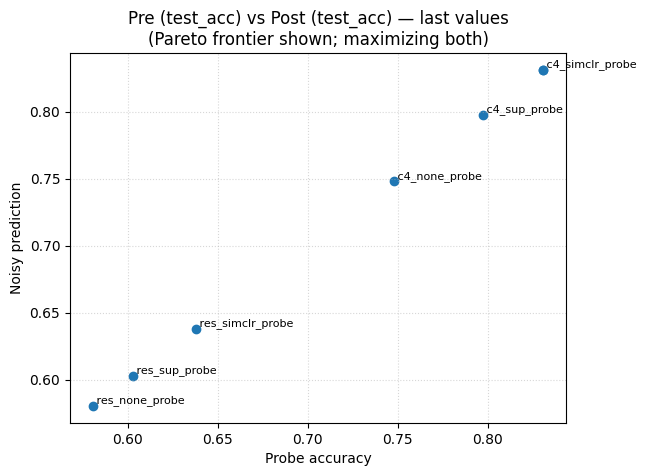

In [227]:
plot_logdict_scatter(
    joint_pre, joint_pre,
    xlabel="Probe accuracy", ylabel="Noisy prediction", pre_column="test_acc", post_column="test_acc", show_diagonal=False
)


{'data':                name        x       y
 0     c4_none_probe  1.00000  0.6620
 1   c4_simclr_probe  0.93274  0.7936
 2      c4_sup_probe  1.00000  0.7322
 3    res_none_probe  0.99988  0.4521
 4  res_simclr_probe  0.84132  0.5970
 5     res_sup_probe  0.99874  0.4834,
 'pareto_names': ['c4_simclr_probe', 'c4_sup_probe']}

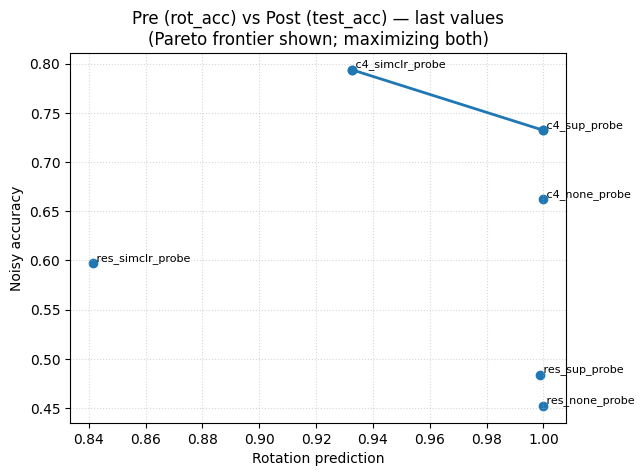

In [228]:
plot_logdict_scatter(
    joint_pre, joint,
    xlabel="Rotation prediction", ylabel="Noisy accuracy", pre_column="rot_acc", post_column="test_acc", show_diagonal=False
)


{'res_none_probe':      epoch  train_acc  test_acc  rot_acc
 0        0    0.19448    0.2116  0.49352
 1        1    0.26502    0.2729  0.59136
 2        2    0.29302    0.2846  0.62048
 3        3    0.31578    0.3078  0.64924
 4        4    0.35032    0.3619  0.67652
 ..     ...        ...       ...      ...
 195    195    0.53256    0.5238  0.99974
 196    196    0.52874    0.5267  0.99980
 197    197    0.53314    0.5246  0.99968
 198    198    0.53354    0.5227  0.99974
 199    199    0.52888    0.5232  0.99974
 
 [200 rows x 4 columns],
 'res_sup_probe':      epoch  train_acc  test_acc  rot_acc
 0        0    0.21162    0.2354  0.52602
 1        1    0.26762    0.2775  0.60198
 2        2    0.29568    0.3155  0.63754
 3        3    0.32838    0.2476  0.66824
 4        4    0.36404    0.3761  0.69166
 ..     ...        ...       ...      ...
 195    195    0.54744    0.5491  0.99844
 196    196    0.54646    0.5505  0.99874
 197    197    0.54828    0.5511  0.99866
 198    198   

AttributeError: module 'matplotlib.pyplot' has no attribute 'vline'

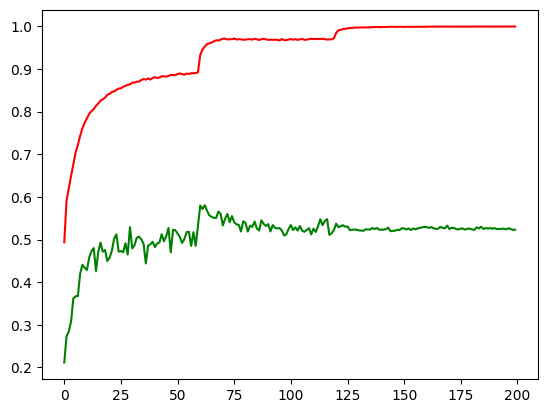

In [237]:
plt.plot(joint_pre['res_none_probe']['rot_acc'], color="red")
plt.plot(joint_pre['res_none_probe']['test_acc'], color="green")
plt.vline(np.argmax(joint_pre['res_none_probe']['test_acc'], color="black", style="--"))

In [232]:
plt.plot(joint_pre['res_simclr_none']['rot_acc'], color="red")
plt.plot(joint_pre['res_simclr_none']['test_acc'], color="green")

KeyError: 'res_simclr_none'

In [238]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=5):
    """Simple moving average smoother."""
    x = np.asarray(x)
    if window is None or window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def plot_joint_pre(
    joint_pre,
    key="res_none_probe",
    smooth_window=5,
    use_smoothed_for_peak=False,
):
    """Plot rot_acc and test_acc with smoothing and a vline at best test epoch."""
    rot_acc = np.asarray(joint_pre[key]["rot_acc"])
    test_acc = np.asarray(joint_pre[key]["test_acc"])

    # Smoothed versions (for nicer curves)
    rot_acc_smooth = moving_average(rot_acc, smooth_window)
    test_acc_smooth = moving_average(test_acc, smooth_window)

    # x-axes (note that smoothed series are shorter)
    x_rot = np.arange(len(rot_acc_smooth))
    x_test = np.arange(len(test_acc_smooth))

    # Epoch of best test accuracy (you can choose raw or smoothed)
    peak_source = test_acc_smooth if use_smoothed_for_peak else test_acc
    peak_idx = int(np.argmax(peak_source))

    fig, ax = plt.subplots()

    ax.plot(x_rot, rot_acc_smooth, color="red", label="rot_acc (smoothed)")
    ax.plot(x_test, test_acc_smooth, color="green", label="test_acc (smoothed)")

    # vertical line at best test epoch (in original index space)
    ax.axvline(x=peak_idx, color="black", linestyle="--", label=f"best test @ {peak_idx}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

    return fig, ax


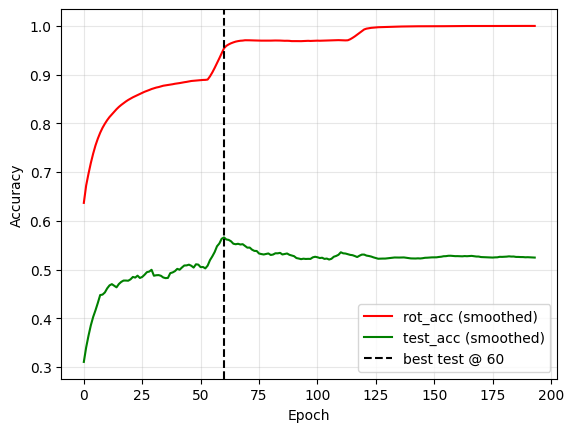

In [245]:
fig, ax = plot_joint_pre(joint_pre, key="res_none_probe",use_smoothed_for_peak=True, smooth_window=7)
plt.show()


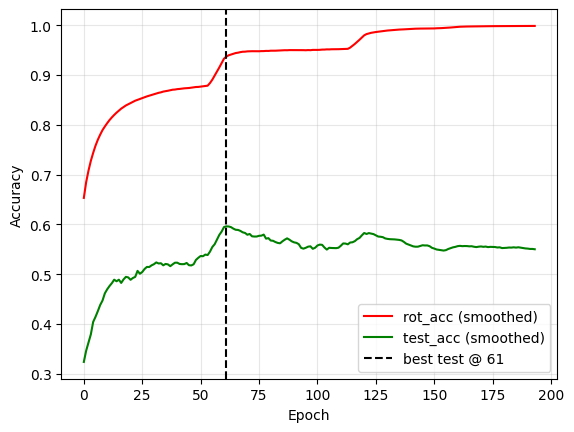

In [246]:
fig, ax = plot_joint_pre(joint_pre, key="res_sup_probe",use_smoothed_for_peak=True, smooth_window=7)
plt.show()

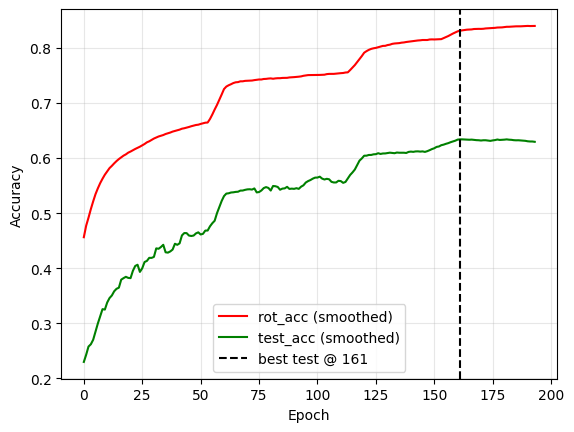

In [247]:
fig, ax = plot_joint_pre(joint_pre, key="res_simclr_probe",use_smoothed_for_peak=True, smooth_window=7)
plt.show()

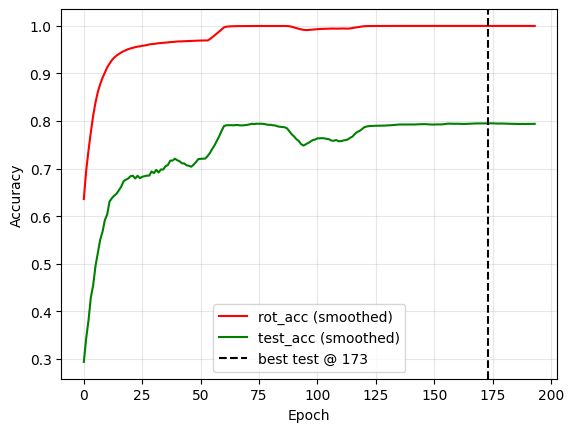

In [253]:
fig, ax = plot_joint_pre(joint_pre, key="c4_sup_probe",use_smoothed_for_peak=True, smooth_window=7)
plt.show()

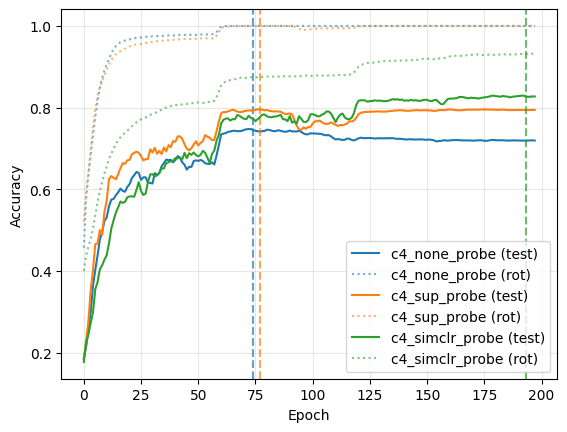

In [259]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=5):
    """Simple moving average smoother."""
    x = np.asarray(x)
    if window is None or window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def plot_joint_pre(
    joint_pre,
    key="res_none_probe",
    smooth_window=5,
    use_smoothed_for_peak=False,
    ax=None,
    color=None,
    label=None,
    plot_rot=False,
):
    """
    Plot (smoothed) test_acc (and optionally rot_acc) and a vline at best test epoch.

    - If `ax` is None, creates a new figure and axes.
    - If `ax` is provided, plots on the existing axes (so you can overlay multiple runs).
    - If `color` is None, uses Matplotlib's default color cycle.
    """
    rot_acc = np.asarray(joint_pre[key]["rot_acc"])
    test_acc = np.asarray(joint_pre[key]["test_acc"])

    # Smooth series
    rot_acc_smooth = moving_average(rot_acc, smooth_window)
    test_acc_smooth = moving_average(test_acc, smooth_window)

    # x-axes for smoothed curves
    x_rot = np.arange(len(rot_acc_smooth))
    x_test = np.arange(len(test_acc_smooth))

    # Decide where the peak is (in *raw* index space)
    if use_smoothed_for_peak:
        peak_s_idx = int(np.argmax(test_acc_smooth))
        # Map smoothed index back to raw index (center of window)
        peak_idx = peak_s_idx + smooth_window // 2
    else:
        peak_idx = int(np.argmax(test_acc))

    # Prepare axes
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    if label is None:
        label = key

    # Plot test_acc
    (line_test,) = ax.plot(
        x_test,
        test_acc_smooth,
        label=f"{label} (test)",
        color=color,
    )

    # Optionally plot rot_acc with lighter alpha
    if plot_rot:
        ax.plot(
            x_rot,
            rot_acc_smooth,
            linestyle=":",
            alpha=0.6,
            label=f"{label} (rot)",
            color=line_test.get_color(),  # same color, different style
        )

    # vline in the same color as the test curve
    vline_color = line_test.get_color()
    ax.axvline(
        x=peak_idx,
        linestyle="--",
        alpha=0.7,
        color=vline_color,
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax
keys   = ["c4_none_probe", "c4_sup_probe", "c4_simclr_probe"]
colors = ["tab:blue", "tab:orange", "tab:green"]  # or any colors you like

fig, ax = None, None
for key, c in zip(keys, colors):
    fig, ax = plot_joint_pre(
        joint_pre,
        key=key,
        use_smoothed_for_peak=True,
        smooth_window=3,
        ax=ax,          # reuse axes
        color=c,        # distinct color per probe
        label=key,
        plot_rot=True, # set True if you also want rot_acc
    )

plt.show()


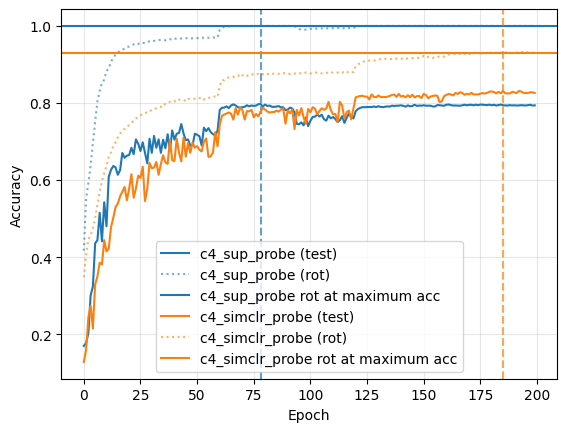

In [265]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=5):
    """Simple moving average smoother."""
    x = np.asarray(x)
    if window is None or window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def plot_joint_pre(
    joint_pre,
    key="res_none_probe",
    smooth_window=5,
    use_smoothed_for_peak=False,
    ax=None,
    color=None,
    label=None,
    plot_rot=False,
):
    """
    Plot (smoothed) test_acc (and optionally rot_acc) and a vline at best test epoch.

    - If `ax` is None, creates a new figure and axes.
    - If `ax` is provided, plots on the existing axes (so you can overlay multiple runs).
    - If `color` is None, uses Matplotlib's default color cycle.
    """
    rot_acc = np.asarray(joint_pre[key]["rot_acc"])
    test_acc = np.asarray(joint_pre[key]["test_acc"])

    # Smooth series
    rot_acc_smooth = moving_average(rot_acc, smooth_window)
    test_acc_smooth = moving_average(test_acc, smooth_window)

    # x-axes for smoothed curves
    x_rot = np.arange(len(rot_acc_smooth))
    x_test = np.arange(len(test_acc_smooth))

    # Decide where the peak is (in *raw* index space)
    if use_smoothed_for_peak:
        peak_s_idx = int(np.argmax(test_acc_smooth))
        # Map smoothed index back to raw index (center of window)
        peak_idx = peak_s_idx + smooth_window // 2
    else:
        peak_idx = int(np.argmax(test_acc))

    # Prepare axes
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    if label is None:
        label = key

    # Plot test_acc
    (line_test,) = ax.plot(
        x_test,
        test_acc_smooth,
        label=f"{label} (test)",
        color=color,
    )

    # Optionally plot rot_acc with lighter alpha
    if plot_rot:
        ax.plot(
            x_rot,
            rot_acc_smooth,
            linestyle=":",
            alpha=0.6,
            label=f"{label} (rot)",
            color=line_test.get_color(),  # same color, different style
        )

    # vline in the same color as the test curve
    vline_color = line_test.get_color()
    ax.axvline(
        x=peak_idx,
        linestyle="--",
        alpha=0.7,
        color=vline_color,
    )

    # --- NEW: horizontal line at rot accuracy at the peak epoch ---
    # Use raw rot_acc at that epoch (clamped just in case)
    peak_idx_clamped = min(max(peak_idx, 0), len(rot_acc) - 1)
    rot_at_peak = rot_acc[peak_idx_clamped]

    ax.axhline(
        y=rot_at_peak,
        color=vline_color,
        label=f"{label} rot at maximum acc",
    )
    # ---------------------------------------------------------------

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax
keys   = ["c4_sup_probe", "c4_simclr_probe"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = None, None
for key, c in zip(keys, colors):
    fig, ax = plot_joint_pre(
        joint_pre,
        key=key,
        use_smoothed_for_peak=True,
        smooth_window=0,
        ax=ax,
        color=c,
        label=key,
        plot_rot=True,
    )

plt.show()

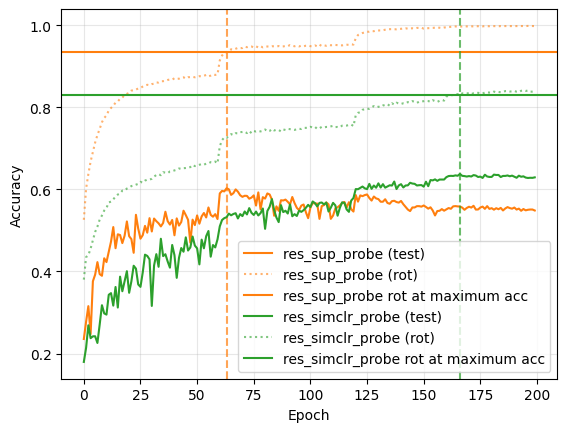

In [267]:
keys   = ["res_sup_probe", "res_simclr_probe"]
colors = ["tab:orange", "tab:green"]

fig, ax = None, None
for key, c in zip(keys, colors):
    fig, ax = plot_joint_pre(
        joint_pre,
        key=key,
        use_smoothed_for_peak=True,
        smooth_window=1,
        ax=ax,
        color=c,
        label=key,
        plot_rot=True,
    )

plt.show()

In [268]:
# at the same level of identifiability, simclr is way more accurate. How can we include this as the explaining away?

In [269]:
# TODO: plot the other none and sup as a function of aug of simclr
# -> Idea augmentation strength attracts the identification curve to the accuracy curve